In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, List
from langchain_core.messages import AnyMessage, RemoveMessage, HumanMessage, AIMessage


## Filter Messages

In [34]:
from langgraph.checkpoint.memory import MemorySaver

llm = ChatGoogleGenerativeAI(model = "gemini-flash-latest", max_retries = 2)


class MessagesState(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]

def filter_message(state: MessagesState):
    # Keep only the last 2 messages (remove older ones)
    if len(state["messages"]) > 2:
        delete_messages = [RemoveMessage(id = m.id) for m in state["messages"][: -2]]
        return {"messages": delete_messages}
    return {}

def node1(state: MessagesState):
    return {"messages": [llm.invoke(state["messages"])]}

builder = StateGraph(MessagesState)

builder.add_node("node1", node1)
builder.add_node("filter", filter_message)

builder.add_edge(START, "filter")
builder.add_edge("filter", "node1")
builder.add_edge("node1", END)

# Add checkpoint writer to persist state across invocations
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

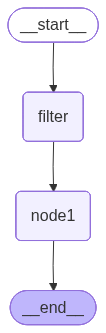

In [36]:
from IPython.display import display, Image

display(Image(graph.get_graph().draw_mermaid_png()))

In [37]:
result = graph.invoke({"messages": HumanMessage(content= "I am Harsh. How can you help me.")}, config={"configurable": {"thread_id": "1"}})

In [38]:
for a in result["messages"]:
    print(a.pretty_print())

================================ Human Message =================================

I am Harsh. How can you help me.
None
================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello Harsh! It’s great to meet you. \n\nAs an AI assistant, I can help you with a wide variety of tasks depending on what you need. Here are some of the main ways I can assist you:\n\n1. **Writing and Editing:** I can help you draft emails, write essays, create resumes, polish your writing, or even write creative stories and poems.\n2. **Learning and Explaining:** If you are studying or just curious, I can explain complex topics (like science, history, or finance) in simple terms.\n3. **Coding and Tech:** I can write code in languages like Python, JavaScript, HTML, C++, etc., help you debug errors, or explain how a piece of code works.\n4. **Brainstorming and Planning:** Need ideas for a project, a gift, a workout routine, or a travel itinerary? I can help you

In [39]:
result = graph.invoke({"messages": HumanMessage(content= "First of all tell me what my name is ?")}, config={"configurable": {"thread_id": "1"}})

In [40]:
for a in result["messages"]:
    print(a.pretty_print())

================================== Ai Message ==================================

[{'type': 'text', 'text': 'Hello Harsh! It’s great to meet you. \n\nAs an AI assistant, I can help you with a wide variety of tasks depending on what you need. Here are some of the main ways I can assist you:\n\n1. **Writing and Editing:** I can help you draft emails, write essays, create resumes, polish your writing, or even write creative stories and poems.\n2. **Learning and Explaining:** If you are studying or just curious, I can explain complex topics (like science, history, or finance) in simple terms.\n3. **Coding and Tech:** I can write code in languages like Python, JavaScript, HTML, C++, etc., help you debug errors, or explain how a piece of code works.\n4. **Brainstorming and Planning:** Need ideas for a project, a gift, a workout routine, or a travel itinerary? I can help you plan and organize them.\n5. **Language and Translation:** I can translate text between different languages or help you 

## Trim Messages

In [42]:
from langchain_core.messages import trim_messages

def trimmed_node(state):
    messages = trim_messages(
        state["messages"], # you pass the state["messages"] inside the trim_messages object.
        max_tokens= 500,
        strategy = "last",
        allow_partial= False,
        include_system = True,
        start_on= "human"
    )

    return {llm.invoke({"messages":messages})}